In [1]:
# Cell 1: Environment Setup
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import time
import os
import gc

# 1. Reproducibility
SEED = 10879360
os.environ['PYTHONHASHSEED'] = str(SEED)
tf.keras.utils.set_random_seed(SEED)

# 2. GPU Memory Growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

# 3. Float32
tf.keras.mixed_precision.set_global_policy('float32')

print("-" * 80)
print(f"TF version : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")
print(f"Precision  : {tf.keras.mixed_precision.global_policy()}")
print("-" * 80)

2026-03-13 12:08:15.101762: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773403695.292526      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773403695.346614      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773403695.776864      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773403695.776908      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773403695.776911      24 computation_placer.cc:177] computation placer alr

✅ GPU Memory Growth Enabled
--------------------------------------------------------------------------------
TF version : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Precision  : <DTypePolicy "float32">
--------------------------------------------------------------------------------


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign


In [3]:
# Cell 2: Data Loading & Preprocessing
# 1. Download GTSRB dataset from Kaggle
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("✅ Dataset downloaded to:", path)

IMG_SIZE        = 96        
BATCH_SIZE      = 64        
TEACHER_EPOCHS  = 15        
STUDENT_EPOCHS  = 10        
AUTOTUNE        = tf.data.AUTOTUNE

TRAIN_DIR   = os.path.join(path, 'Train')
num_classes = 43
class_names = [str(i) for i in range(num_classes)]

raw_train = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    seed=SEED
)

test_csv    = pd.read_csv(os.path.join(path, 'Test.csv'))
test_paths  = [os.path.join(path, p) for p in test_csv['Path'].values]
test_labels = test_csv['ClassId'].values.astype(int)

def normalize(img, label):
    return tf.cast(img, tf.float32) / 255.0, label

def load_test_image(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

train_ds = (
    raw_train
    .map(normalize, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=1000, seed=SEED)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
    .map(load_test_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

counts        = [len(os.listdir(os.path.join(TRAIN_DIR, str(i)))) for i in range(num_classes)]
total_samples = sum(counts)
class_weights = {i: total_samples / (num_classes * counts[i]) for i in range(num_classes)}

print("-" * 30)
print(f"Classes        : {num_classes}")
print(f"Train samples  : {total_samples}")
print(f"Test samples   : {len(test_csv)}")
print(f"Teacher epochs : {TEACHER_EPOCHS}")
print(f"Student epochs : {STUDENT_EPOCHS}")
print("-" * 30)

✅ Dataset downloaded to: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
Found 39209 files belonging to 43 classes.


I0000 00:00:1773403732.623662      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


------------------------------
Classes        : 43
Train samples  : 39209
Test samples   : 12630
Teacher epochs : 15
Student epochs : 10
------------------------------


In [4]:
# Cell 3: Phase 1 - Teacher Training
def build_teacher():
    data_augmentation = tf.keras.Sequential([
        layers.RandomBrightness(factor=0.2, value_range=(0.0, 1.0), seed=SEED),
        layers.RandomContrast(factor=0.2, seed=SEED),
        layers.RandomZoom(height_factor=0.05, width_factor=0.05, seed=SEED),
    ], name='Safe_Augmentation')
 
    base = applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
 
    base.trainable = True
    for layer in base.layers[:-60]:  # top 60 layers unfrozen
        layer.trainable = False
 
    return models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(num_classes)
    ], name='Teacher_MobileNetV2')
 
 
teacher_model = build_teacher()
teacher_model.summary()
 
teacher_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
 
teacher_history = teacher_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TEACHER_EPOCHS,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ],
    verbose=1
)
 
teacher_test_loss, teacher_test_acc = teacher_model.evaluate(val_ds, verbose=0)
print(f"Teacher Test Accuracy: {teacher_test_acc * 100:.2f}%")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Teacher_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Safe_Augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 43)             │        55,083 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,313,067 (8.82 MB)

 Trainable params: 2,010,795 (7.67 MB)

 Non-trainable params: 302,272 (1.15 MB)

Epoch 1/15


I0000 00:00:1773403783.031944      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


613/613 ━━━━━━━━━━━━━━━━━━━━ 87s 62ms/step - accuracy: 0.1094 - loss: 3.7126 - val_accuracy: 0.3481 - val_loss: 2.3490 - learning_rate: 1.0000e-05
Epoch 2/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.4705 - loss: 1.7683 - val_accuracy: 0.5578 - val_loss: 1.4891 - learning_rate: 1.0000e-05
Epoch 3/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.6424 - loss: 1.0750 - val_accuracy: 0.6604 - val_loss: 1.0817 - learning_rate: 1.0000e-05
Epoch 4/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.7353 - loss: 0.7467 - val_accuracy: 0.7213 - val_loss: 0.8588 - learning_rate: 1.0000e-05
Epoch 5/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.7969 - loss: 0.5441 - val_accuracy: 0.7627 - val_loss: 0.7325 - learning_rate: 1.0000e-05
Epoch 6/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.8381 - loss: 0.4212 - val_accuracy: 0.7971 - val_loss: 0.6361 - learning_rate: 1.0000e-05
Epoch 7/15
613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accurac

In [5]:
# Cell 4: Phase 2 - Student Baseline Training (~35K params, no KD)
def build_student():
    return models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.SeparableConv2D(32,  (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.SeparableConv2D(64,  (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.SeparableConv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes)
    ], name='Student_MicroCNN')

tf.keras.utils.set_random_seed(SEED)
student_baseline = build_student()
student_baseline.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f"Student params: {student_baseline.count_params():,}")
baseline_history = student_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STUDENT_EPOCHS,
    class_weight=class_weights,
    verbose=1
)

Student params: 34,406
Epoch 1/10


I0000 00:00:1773404234.479211      73 service.cc:152] XLA service 0x7aac542ad810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773404234.479259      73 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773404240.193732      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.1021 - loss: 3.1765 - val_accuracy: 0.1158 - val_loss: 3.0940
Epoch 2/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.2394 - loss: 2.3675 - val_accuracy: 0.2283 - val_loss: 2.6709
Epoch 3/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.3400 - loss: 1.9036 - val_accuracy: 0.2679 - val_loss: 2.4260
Epoch 4/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.4319 - loss: 1.5529 - val_accuracy: 0.3211 - val_loss: 2.2083
Epoch 5/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5156 - loss: 1.2700 - val_accuracy: 0.3512 - val_loss: 2.1147
Epoch 6/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5766 - loss: 1.0480 - val_accuracy: 0.4144 - val_loss: 1.9362
Epoch 7/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6339 - loss: 0.8692 - val_accuracy: 0.4780 - val_loss: 1.7599
Epoch 8/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6828 - loss: 0.7206 - val_accurac

In [6]:
# Cell 5: Phase 3 — Knowledge Distillation
class Distiller(tf.keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher      = teacher
        self.student      = student
        self.loss_tracker = tf.keras.metrics.Mean(name='loss')
        self.acc_tracker  = tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')

    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_tracker]

    def compile(self, optimizer, metrics, student_loss_fn,
                distillation_loss_fn, alpha=0.1, temperature=3):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn      = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha       = alpha
        self.temperature = temperature

    def train_step(self, data):
        if len(data) == 3:
            x, y, sample_weight = data
        else:
            x, y = data
            sample_weight = None

        t_logits = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            s_logits = self.student(x, training=True)
            hard_loss = self.student_loss_fn(y, s_logits, sample_weight=sample_weight)
            soft_targets     = tf.nn.softmax(tf.cast(t_logits, tf.float32) / self.temperature, axis=1)
            soft_predictions = tf.nn.softmax(tf.cast(s_logits, tf.float32) / self.temperature, axis=1)
            soft_loss = self.distillation_loss_fn(soft_targets, soft_predictions)
            loss = (self.alpha * hard_loss +
                    (1 - self.alpha) * (self.temperature ** 2) * soft_loss)

        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self.loss_tracker.update_state(loss)
        self.acc_tracker.update_state(y, s_logits, sample_weight=sample_weight)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        if len(data) == 3:
            x, y, sample_weight = data
        else:
            x, y = data
            sample_weight = None
        s_logits = self.student(x, training=False)
        self.acc_tracker.update_state(y, s_logits, sample_weight=sample_weight)
        return {m.name: m.result() for m in self.metrics}


kd_results   = {}
kd_histories = {}
kd_students  = {}

temperatures = [3, 5, 10]
alphas       = [0.1, 0.3, 0.5]

print("=" * 55)
print("3x3 KD Grid Search  (T x alpha = 9 conditions)")
print("=" * 55)

for T in temperatures:
    for alpha in alphas:
        exp_key = f"T={T}_a={alpha}"
        print(f"\n--- KD  T={T}  alpha={alpha} ---")

        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED)

        student_kd = build_student()

        distiller = Distiller(student=student_kd, teacher=teacher_model)
        distiller.compile(
            optimizer=optimizers.Adam(1e-3),
            metrics=['accuracy'],
            student_loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            distillation_loss_fn=tf.keras.losses.KLDivergence(),
            alpha=alpha,
            temperature=T
        )

        history = distiller.fit(
            train_ds,
            validation_data=val_ds,
            epochs=STUDENT_EPOCHS,
            class_weight=class_weights,
            verbose=1
        )

        kd_results[exp_key]   = max(history.history['val_accuracy'])
        kd_histories[exp_key] = history
        kd_students[exp_key]  = student_kd

        del distiller
        gc.collect()


print("\n" + "=" * 55)
print("Grid Search Results")
print("=" * 55)
print(f"\n{'':>10}", end="")
for alpha in alphas:
    print(f"  a={alpha}", end="")
print()
print("-" * 40)
for T in temperatures:
    print(f"T={T:<8}", end="")
    for alpha in alphas:
        key = f"T={T}_a={alpha}"
        acc = kd_results[key] * 100
        marker = " *" if acc == max(v * 100 for v in kd_results.values()) else ""
        print(f"  {acc:.2f}%{marker}", end="")
    print()

best_key = max(kd_results, key=kd_results.get)
print(f"\nBest: {best_key}  ->  {kd_results[best_key]*100:.2f}%")

3x3 KD Grid Search  (T x alpha = 9 conditions)

--- KD  T=3  alpha=0.1 ---
Epoch 1/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.0961 - loss: 11.6413 - val_accuracy: 0.1632 - val_loss: 0.0000e+00
Epoch 2/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.2542 - loss: 8.7857 - val_accuracy: 0.3860 - val_loss: 0.0000e+00
Epoch 3/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.3645 - loss: 6.8951 - val_accuracy: 0.4579 - val_loss: 0.0000e+00
Epoch 4/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.4620 - loss: 5.7473 - val_accuracy: 0.5253 - val_loss: 0.0000e+00
Epoch 5/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.5646 - loss: 4.8997 - val_accuracy: 0.5549 - val_loss: 0.0000e+00
Epoch 6/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.6472 - loss: 4.1906 - val_accuracy: 0.6034 - val_loss: 0.0000e+00
Epoch 7/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.7243 - loss: 3.5578 - val_accuracy: 0.6846 - val_los

In [7]:
# Cell 6: Inference Latency Measurement
def measure_latency(model, data, batch_size=1, warmup=10, runs=100):
    for _ in range(warmup):
        model.predict(data[:batch_size], verbose=0, batch_size=batch_size)

    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        model.predict(data[:batch_size], verbose=0, batch_size=batch_size)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000)

    return float(np.mean(times)), float(np.std(times))

rng    = np.random.default_rng(SEED)
sample = rng.random((100, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)

latency_results = {}

print("Measuring Student Baseline latency...")
latency_results['Baseline'] = measure_latency(student_baseline, sample)

for exp_key, model in kd_students.items():
    print(f"Measuring {exp_key} latency...")
    latency_results[exp_key] = measure_latency(model, sample)

# Print results 
print("\n" + "=" * 55)
print("Inference Latency Results  (batch_size=1, 100 runs)")
print("=" * 55)
print(f"{'Model':<22} {'Mean (ms/img)':>14} {'Std (ms/img)':>14}")
print("-" * 52)
for label, (mean_ms, std_ms) in latency_results.items():
    print(f"{label:<22} {mean_ms:>13.4f}  {std_ms:>12.4f}")

# Max spread across all KD students
kd_means = [v[0] for k, v in latency_results.items() if k != 'Baseline']
spread   = max(kd_means) - min(kd_means)
print("-" * 52)
print(f"\nMax spread across KD conditions : {spread:.4f} ms")
print("(Near-zero spread confirms zero computational overhead")
print(" from KD hyperparameter choice at inference time)")

Measuring Student Baseline latency...
Measuring T=3_a=0.1 latency...
Measuring T=3_a=0.3 latency...
Measuring T=3_a=0.5 latency...
Measuring T=5_a=0.1 latency...
Measuring T=5_a=0.3 latency...
Measuring T=5_a=0.5 latency...
Measuring T=10_a=0.1 latency...
Measuring T=10_a=0.3 latency...
Measuring T=10_a=0.5 latency...

Inference Latency Results  (batch_size=1, 100 runs)
Model                   Mean (ms/img)   Std (ms/img)
----------------------------------------------------
Baseline                     54.0090        2.9578
T=3_a=0.1                    53.7268        2.2232
T=3_a=0.3                    53.6843        2.4572
T=3_a=0.5                    54.8249        3.4831
T=5_a=0.1                    53.7390        2.0832
T=5_a=0.3                    55.0336        3.4224
T=5_a=0.5                    53.7606        2.2845
T=10_a=0.1                   53.9136        2.3682
T=10_a=0.3                   55.1943        3.7850
T=10_a=0.5                   54.4397        2.4079
-----------

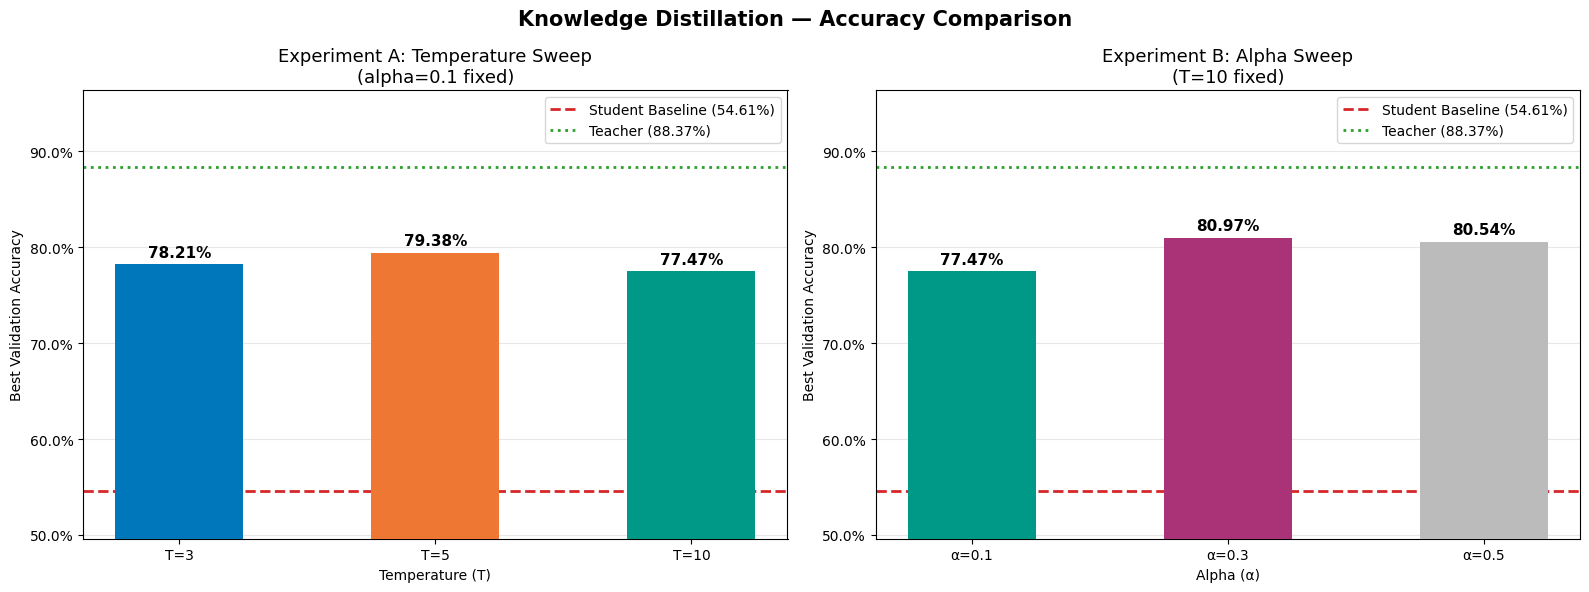

Saved: kd_accuracy_comparison.png


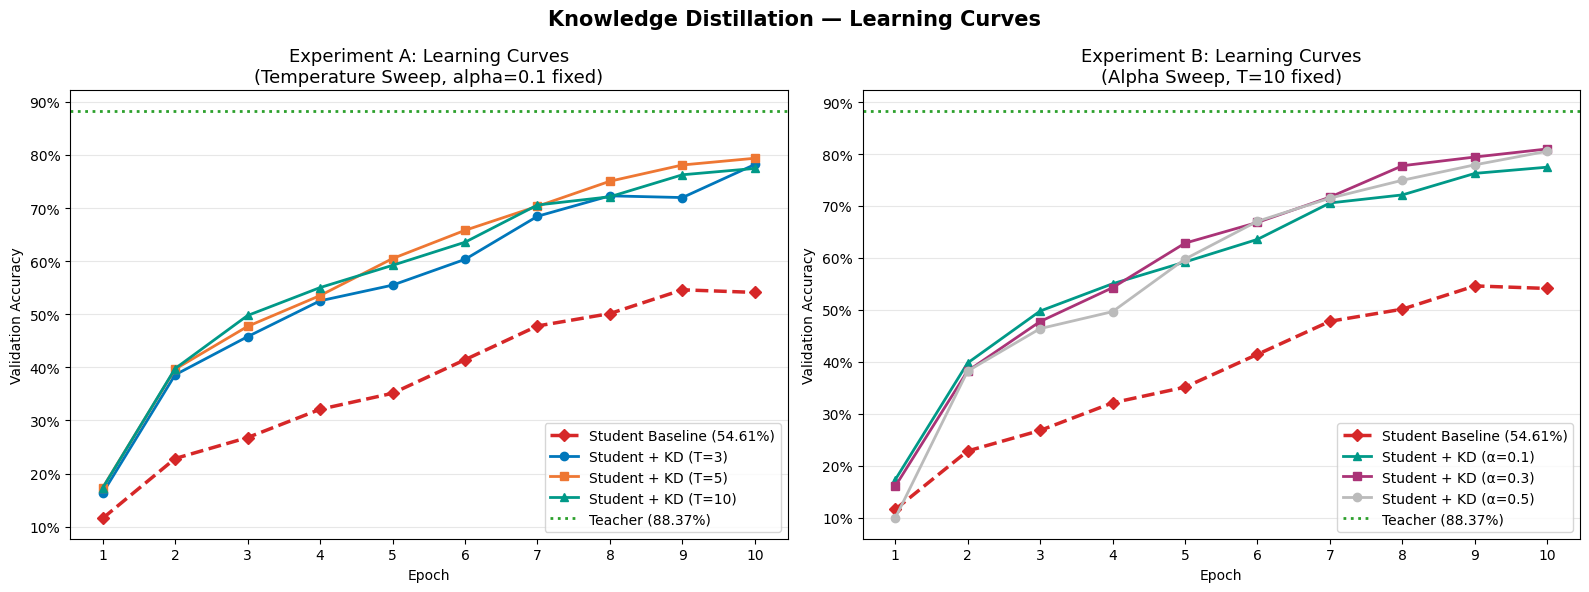

Saved: kd_learning_curves.png


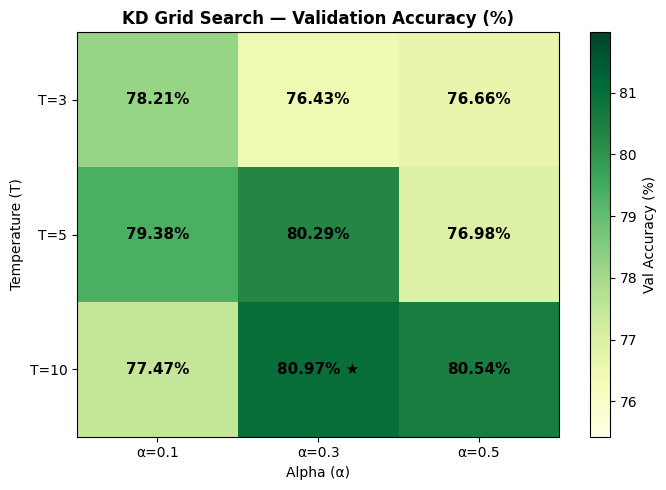

Saved: kd_grid_heatmap.png

Summary Table — All Experimental Conditions
Model                         Params   Best Val Acc   vs Baseline
-----------------------------------------------------------------
Teacher (MobileNetV2)      2,313,067        88.37%             —
Student Baseline              34,406        54.61%       0.00 pp
KD (T=3_a=0.1)                34,406        78.21%     +23.60 pp
KD (T=3_a=0.3)                34,406        76.43%     +21.82 pp
KD (T=3_a=0.5)                34,406        76.66%     +22.05 pp
KD (T=5_a=0.1)                34,406        79.38%     +24.77 pp
KD (T=5_a=0.3)                34,406        80.29%     +25.68 pp
KD (T=5_a=0.5)                34,406        76.98%     +22.37 pp
KD (T=10_a=0.1)               34,406        77.47%     +22.86 pp
KD (T=10_a=0.3)               34,406        80.97%     +26.37 pp
KD (T=10_a=0.5)               34,406        80.54%     +25.93 pp


In [8]:
# Cell 7: Visualisation
t_acc = max(teacher_history.history['val_accuracy'])
b_acc = max(baseline_history.history['val_accuracy'])
 
t_sweep_keys = [f"T={T}_a=0.1"   for T in [3, 5, 10]]
a_sweep_keys = [f"T=10_a={alpha}" for alpha in [0.1, 0.3, 0.5]]
 
t_sweep_accs = [kd_results[k] for k in t_sweep_keys]
a_sweep_accs = [kd_results[k] for k in a_sweep_keys]
 
t_labels = ['T=3', 'T=5', 'T=10']
a_labels = ['α=0.1', 'α=0.3', 'α=0.5']
 
epochs_range = range(1, STUDENT_EPOCHS + 1)
 
C_TEACHER  = '#2ca02c'
C_BASELINE = '#d62728'
C_T3       = '#0077BB'
C_T5       = '#EE7733'
C_T10      = '#009988'
C_A01      = '#009988'
C_A03      = '#AA3377'
C_A05      = '#BBBBBB'
 
kd_t_styles = {
    'T=3_a=0.1':  {'color': C_T3,  'marker': 'o', 'ls': '-'},
    'T=5_a=0.1':  {'color': C_T5,  'marker': 's', 'ls': '-'},
    'T=10_a=0.1': {'color': C_T10, 'marker': '^', 'ls': '-'},
}
kd_a_styles = {
    'T=10_a=0.1': {'color': C_A01, 'marker': '^', 'ls': '-'},
    'T=10_a=0.3': {'color': C_A03, 'marker': 's', 'ls': '-'},
    'T=10_a=0.5': {'color': C_A05, 'marker': 'o', 'ls': '-'},
}
 
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig1.suptitle('Knowledge Distillation — Accuracy Comparison', fontsize=15, fontweight='bold')
 
bar_colors_t = [C_T3, C_T5, C_T10]
bars1 = ax1.bar(t_labels, t_sweep_accs, color=bar_colors_t, width=0.5, zorder=3)
ax1.axhline(b_acc, color=C_BASELINE, ls='--', lw=2, label=f'Student Baseline ({b_acc:.2%})')
ax1.axhline(t_acc, color=C_TEACHER,  ls=':',  lw=2, label=f'Teacher ({t_acc:.2%})')
for bar, acc in zip(bars1, t_sweep_accs):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_title('Experiment A: Temperature Sweep\n(alpha=0.1 fixed)', fontsize=13)
ax1.set_xlabel('Temperature (T)')
ax1.set_ylabel('Best Validation Accuracy')
ax1.set_ylim(b_acc - 0.05, min(t_acc + 0.08, 1.0))
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.grid(axis='y', alpha=0.3, zorder=0)
ax1.legend(fontsize=10)
 
bar_colors_a = [C_A01, C_A03, C_A05]
bars2 = ax2.bar(a_labels, a_sweep_accs, color=bar_colors_a, width=0.5, zorder=3)
ax2.axhline(b_acc, color=C_BASELINE, ls='--', lw=2, label=f'Student Baseline ({b_acc:.2%})')
ax2.axhline(t_acc, color=C_TEACHER,  ls=':',  lw=2, label=f'Teacher ({t_acc:.2%})')
for bar, acc in zip(bars2, a_sweep_accs):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_title('Experiment B: Alpha Sweep\n(T=10 fixed)', fontsize=13)
ax2.set_xlabel('Alpha (α)')
ax2.set_ylabel('Best Validation Accuracy')
ax2.set_ylim(b_acc - 0.05, min(t_acc + 0.08, 1.0))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.grid(axis='y', alpha=0.3, zorder=0)
ax2.legend(fontsize=10)
 
plt.tight_layout()
plt.savefig('kd_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kd_accuracy_comparison.png")
 
 
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle('Knowledge Distillation — Learning Curves', fontsize=15, fontweight='bold')
 
ax3.plot(epochs_range, baseline_history.history['val_accuracy'],
         color=C_BASELINE, ls='--', lw=2.5, marker='D', ms=6,
         label=f'Student Baseline ({b_acc:.2%})')
for key in t_sweep_keys:
    s = kd_t_styles[key]
    ax3.plot(epochs_range, kd_histories[key].history['val_accuracy'],
             color=s['color'], ls=s['ls'], lw=2, marker=s['marker'], ms=6,
             label=f"Student + KD ({key.replace('_a=0.1', '')})")
ax3.axhline(t_acc, color=C_TEACHER, ls=':', lw=2, label=f'Teacher ({t_acc:.2%})')
ax3.set_title('Experiment A: Learning Curves\n(Temperature Sweep, alpha=0.1 fixed)', fontsize=13)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Validation Accuracy')
ax3.set_xticks(list(epochs_range))
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax3.grid(axis='y', alpha=0.3)
ax3.legend(fontsize=10)
 
ax4.plot(epochs_range, baseline_history.history['val_accuracy'],
         color=C_BASELINE, ls='--', lw=2.5, marker='D', ms=6,
         label=f'Student Baseline ({b_acc:.2%})')
for key in a_sweep_keys:
    s = kd_a_styles[key]
    alpha_val = key.split('_a=')[1]
    ax4.plot(epochs_range, kd_histories[key].history['val_accuracy'],
             color=s['color'], ls=s['ls'], lw=2, marker=s['marker'], ms=6,
             label=f'Student + KD (α={alpha_val})')
ax4.axhline(t_acc, color=C_TEACHER, ls=':', lw=2, label=f'Teacher ({t_acc:.2%})')
ax4.set_title('Experiment B: Learning Curves\n(Alpha Sweep, T=10 fixed)', fontsize=13)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Validation Accuracy')
ax4.set_xticks(list(epochs_range))
ax4.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax4.grid(axis='y', alpha=0.3)
ax4.legend(fontsize=10)
 
plt.tight_layout()
plt.savefig('kd_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kd_learning_curves.png")
 
 
# Grid heatmap — all 9 conditions
temperatures = [3, 5, 10]
alphas       = [0.1, 0.3, 0.5]
grid_data    = np.array([[kd_results[f"T={T}_a={alpha}"] * 100
                          for alpha in alphas]
                         for T in temperatures])
 
fig3, ax5 = plt.subplots(figsize=(7, 5))
im = ax5.imshow(grid_data, cmap='YlGn', aspect='auto',
                vmin=grid_data.min() - 1, vmax=grid_data.max() + 1)
plt.colorbar(im, ax=ax5, label='Val Accuracy (%)')
ax5.set_xticks(range(len(alphas)))
ax5.set_yticks(range(len(temperatures)))
ax5.set_xticklabels([f'α={a}' for a in alphas])
ax5.set_yticklabels([f'T={T}' for T in temperatures])
ax5.set_xlabel('Alpha (α)')
ax5.set_ylabel('Temperature (T)')
ax5.set_title('KD Grid Search — Validation Accuracy (%)', fontweight='bold')
best_val = grid_data.max()
for i in range(len(temperatures)):
    for j in range(len(alphas)):
        marker = ' ★' if grid_data[i, j] == best_val else ''
        ax5.text(j, i, f'{grid_data[i, j]:.2f}%{marker}',
                 ha='center', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('kd_grid_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kd_grid_heatmap.png")
 
 
# Summary Table — all 9 conditions
print("\n" + "=" * 65)
print("Summary Table — All Experimental Conditions")
print("=" * 65)
print(f"{'Model':<25} {'Params':>10} {'Best Val Acc':>14} {'vs Baseline':>13}")
print("-" * 65)
print(f"{'Teacher (MobileNetV2)':<25} {'2,313,067':>10} {t_acc:>13.2%} {'—':>13}")
print(f"{'Student Baseline':<25} {'34,406':>10} {b_acc:>13.2%} {'0.00 pp':>13}")
for T in [3, 5, 10]:
    for alpha in [0.1, 0.3, 0.5]:
        key  = f"T={T}_a={alpha}"
        acc  = kd_results[key]
        diff = (acc - b_acc) * 100
        print(f"{'KD (' + key + ')':<25} {'34,406':>10} {acc:>13.2%} {f'+{diff:.2f} pp':>13}")
print("=" * 65)

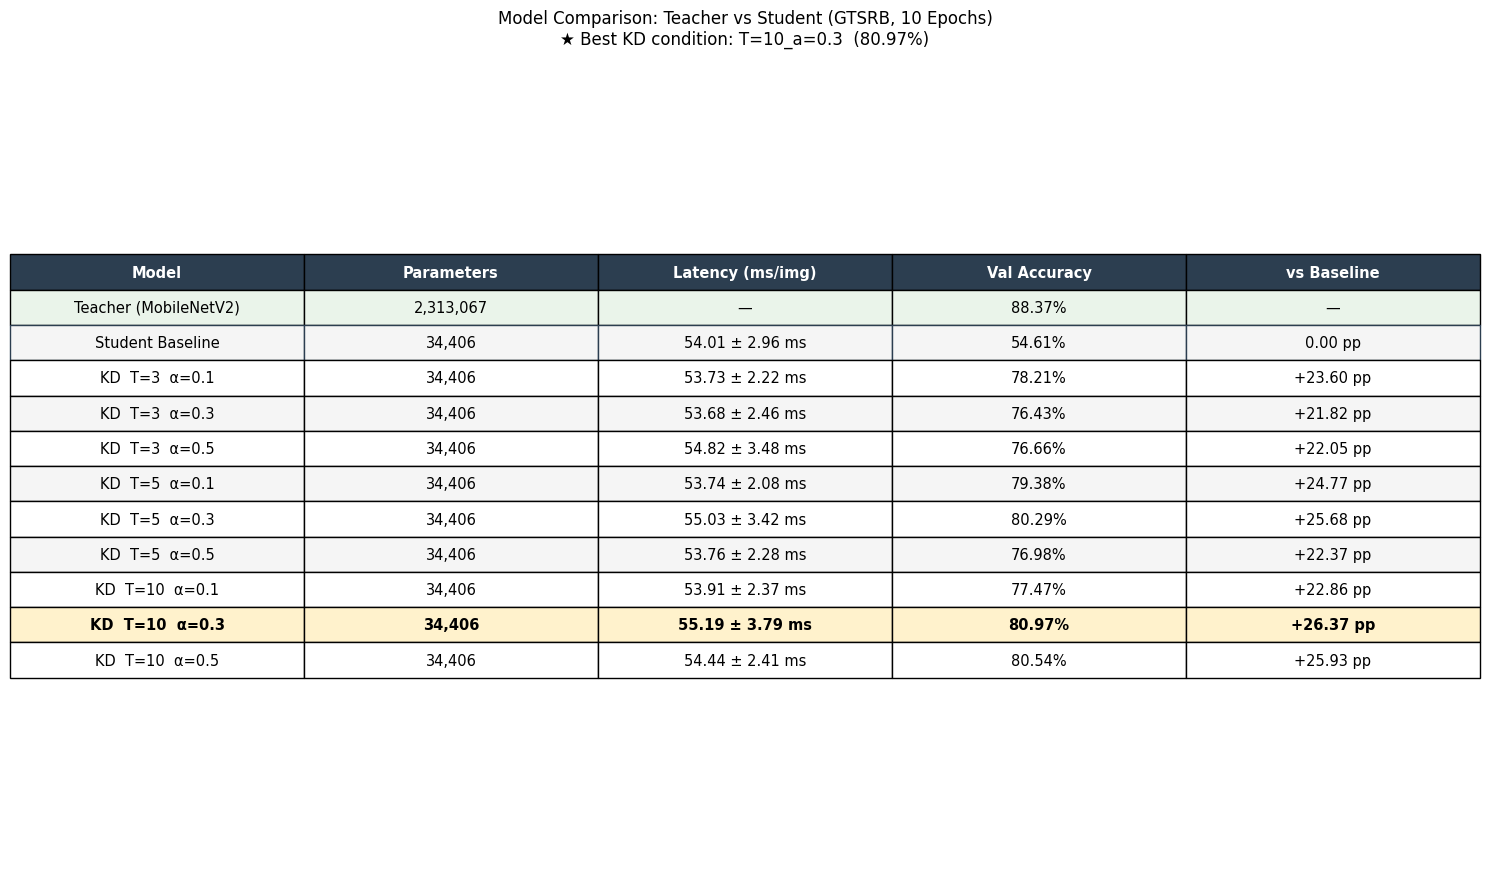

Saved: kd_table.png


In [9]:
# Cell 8: Summary Table
def fmt_latency(key):
    if key not in latency_results:
        return '—'
    mean_ms, std_ms = latency_results[key]
    return f'{mean_ms:.2f} ± {std_ms:.2f} ms'

def fmt_acc(acc):
    return f'{acc:.2%}'

b_acc = max(baseline_history.history['val_accuracy'])
t_acc = max(teacher_history.history['val_accuracy'])

rows = []
rows.append([
    'Teacher (MobileNetV2)',
    f'{teacher_model.count_params():,}',
    '—',
    fmt_acc(t_acc),
    '—'
])
rows.append([
    'Student Baseline',
    f'{student_baseline.count_params():,}',
    fmt_latency('Baseline'),
    fmt_acc(b_acc),
    '0.00 pp'
])

# All 9 KD conditions
all_kd_keys = []
for T in [3, 5, 10]:
    for alpha in [0.1, 0.3, 0.5]:
        key  = f'T={T}_a={alpha}'
        acc  = kd_results[key]
        diff = (acc - b_acc) * 100
        rows.append([
            f'KD  T={T}  α={alpha}',
            f'{kd_students[key].count_params():,}',
            fmt_latency(key),
            fmt_acc(acc),
            f'+{diff:.2f} pp'
        ])
        all_kd_keys.append(key)

cols = ['Model', 'Parameters', 'Latency (ms/img)', 'Val Accuracy', 'vs Baseline']

best_key     = max(kd_results, key=kd_results.get)
best_acc     = kd_results[best_key]
best_row_idx = all_kd_keys.index(best_key) + 2  # +2 for Teacher + Baseline rows

fig, ax = plt.subplots(figsize=(15, len(rows) * 0.7 + 1.2))
ax.axis('off')
tbl = ax.table(
    cellText=rows,
    colLabels=cols,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)
tbl.scale(1, 1.8)

for j in range(len(cols)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(rows) + 1):
    for j in range(len(cols)):
        tbl[i, j].set_facecolor('#f5f5f5' if i % 2 == 0 else '#ffffff')

for j in range(len(cols)):
    tbl[1, j].set_facecolor('#eaf4ea')

for j in range(len(cols)):
    tbl[best_row_idx + 1, j].set_facecolor('#fff2cc')
    tbl[best_row_idx + 1, j].set_text_props(fontweight='bold')

for j in range(len(cols)):
    tbl[2, j].set_edgecolor('#2c3e50')

plt.title(
    f'Model Comparison: Teacher vs Student (GTSRB, {STUDENT_EPOCHS} Epochs)\n'
    f'★ Best KD condition: {best_key}  ({best_acc:.2%})',
    fontsize=12, pad=14
)
plt.tight_layout()
plt.savefig('kd_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kd_table.png")

Best KD condition: T=10_a=0.3  (80.97%)

Baseline accuracy  : 54.12%
KD (T=10_a=0.3) accuracy: 80.97%


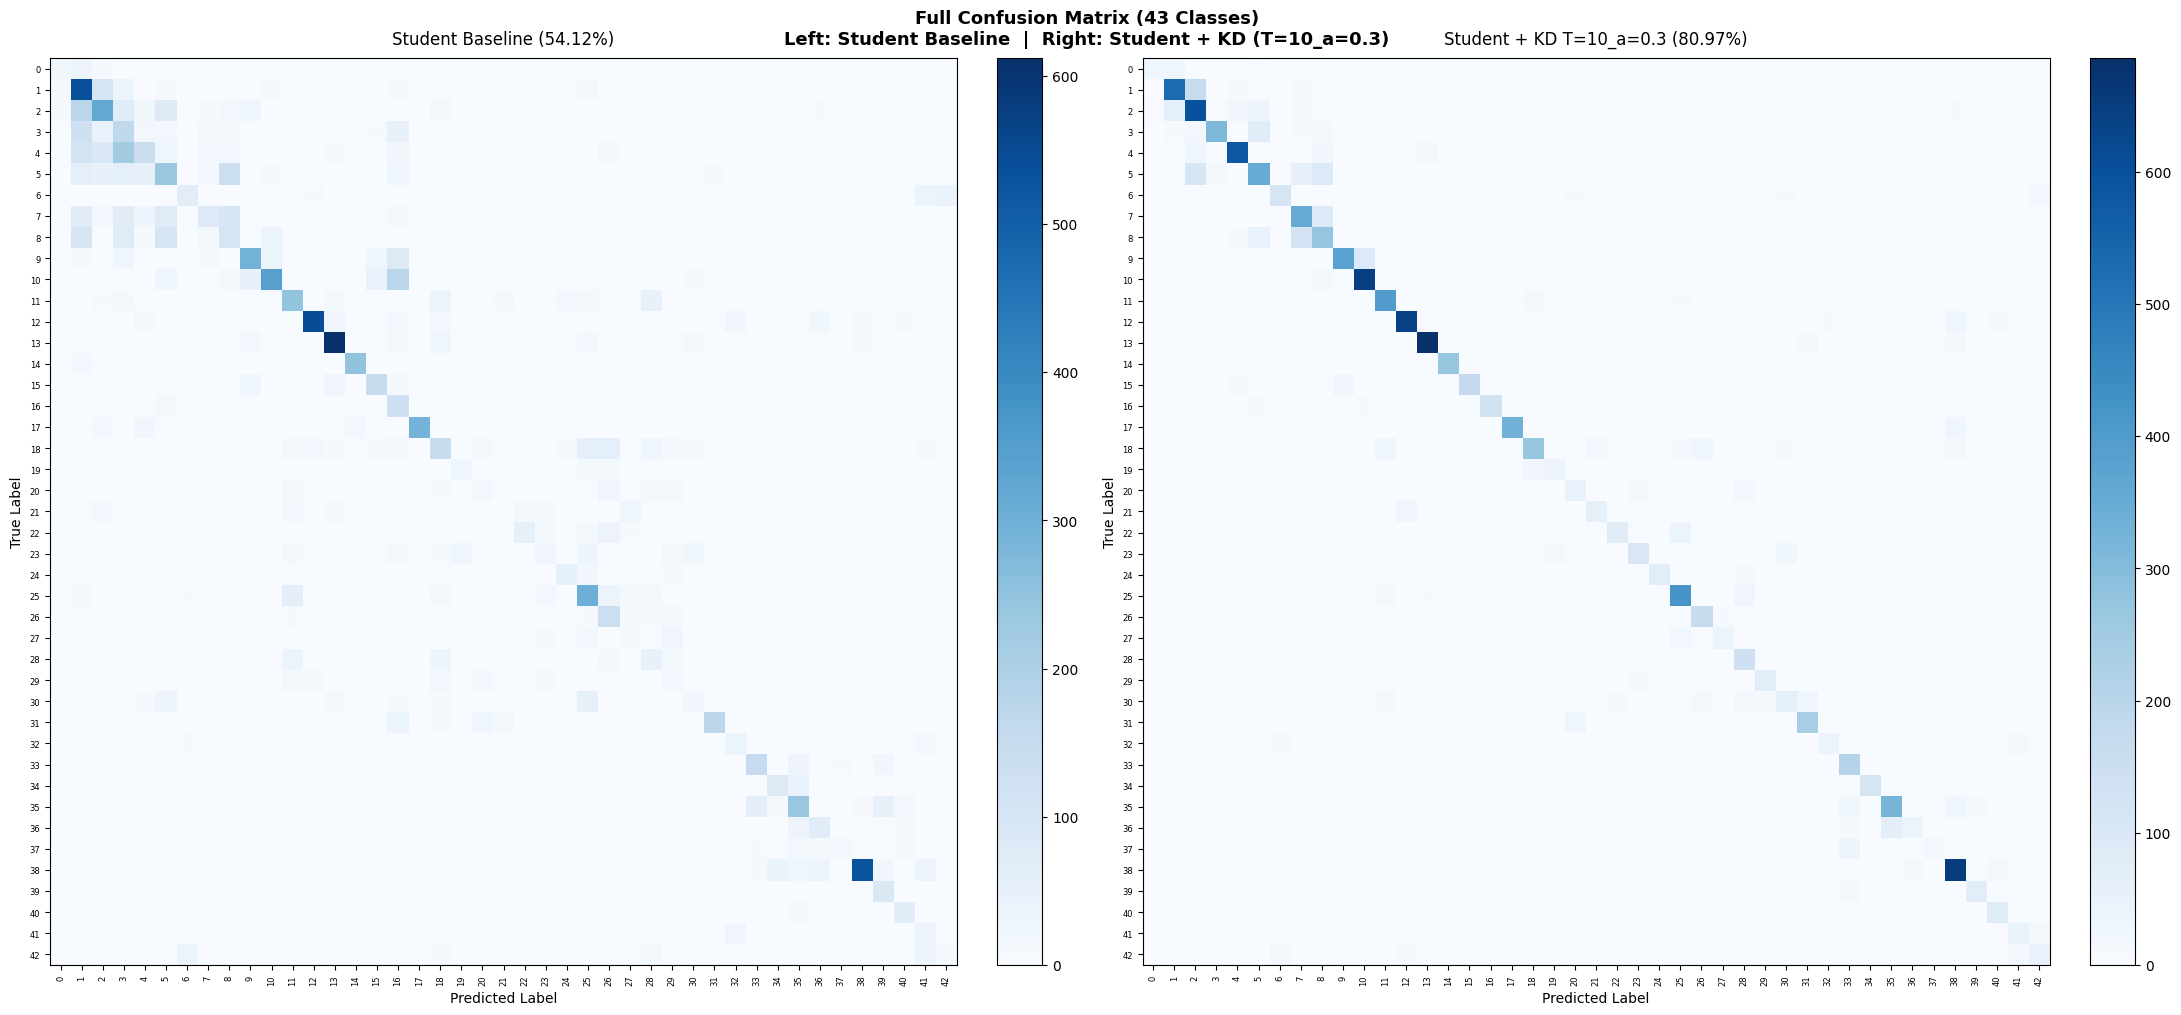

Saved: confusion_matrix_full.png


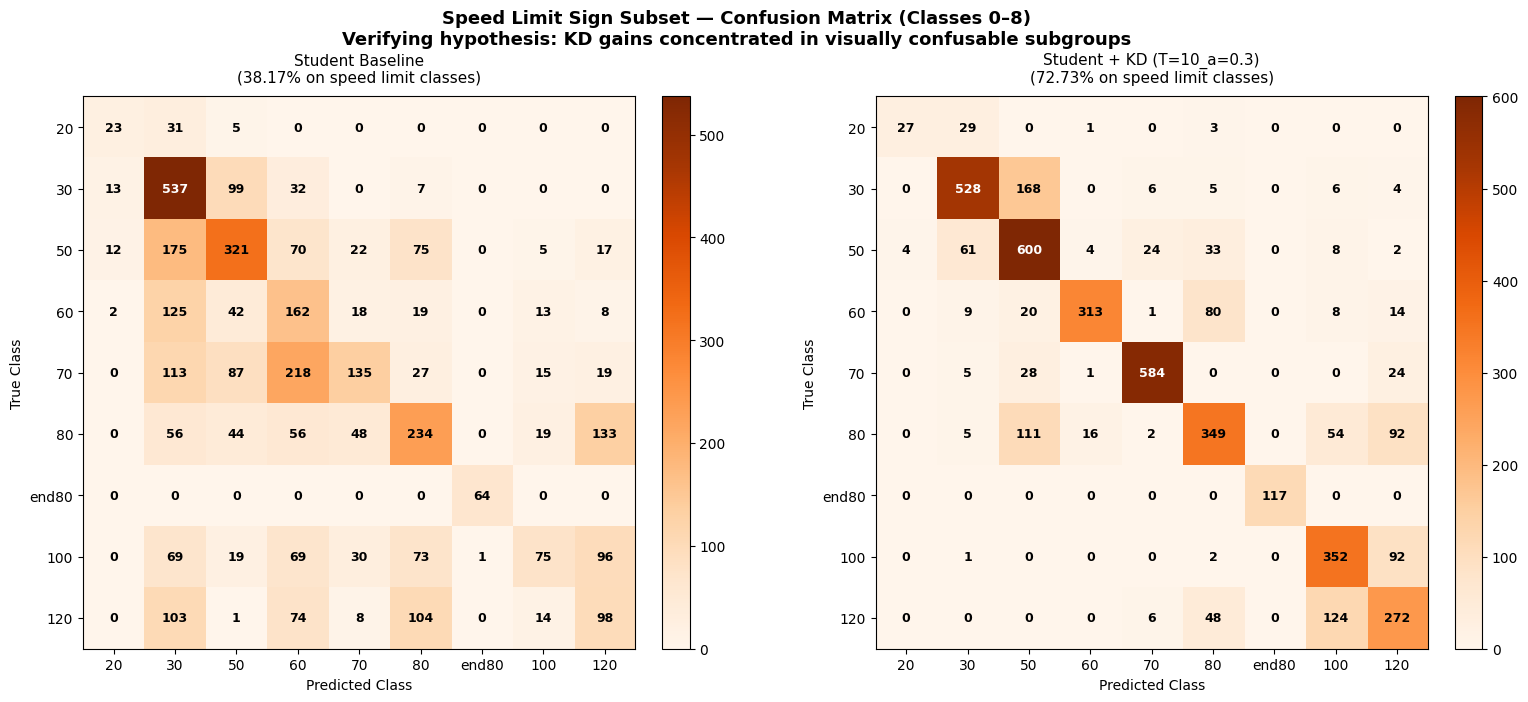

Saved: confusion_matrix_speed_limit.png


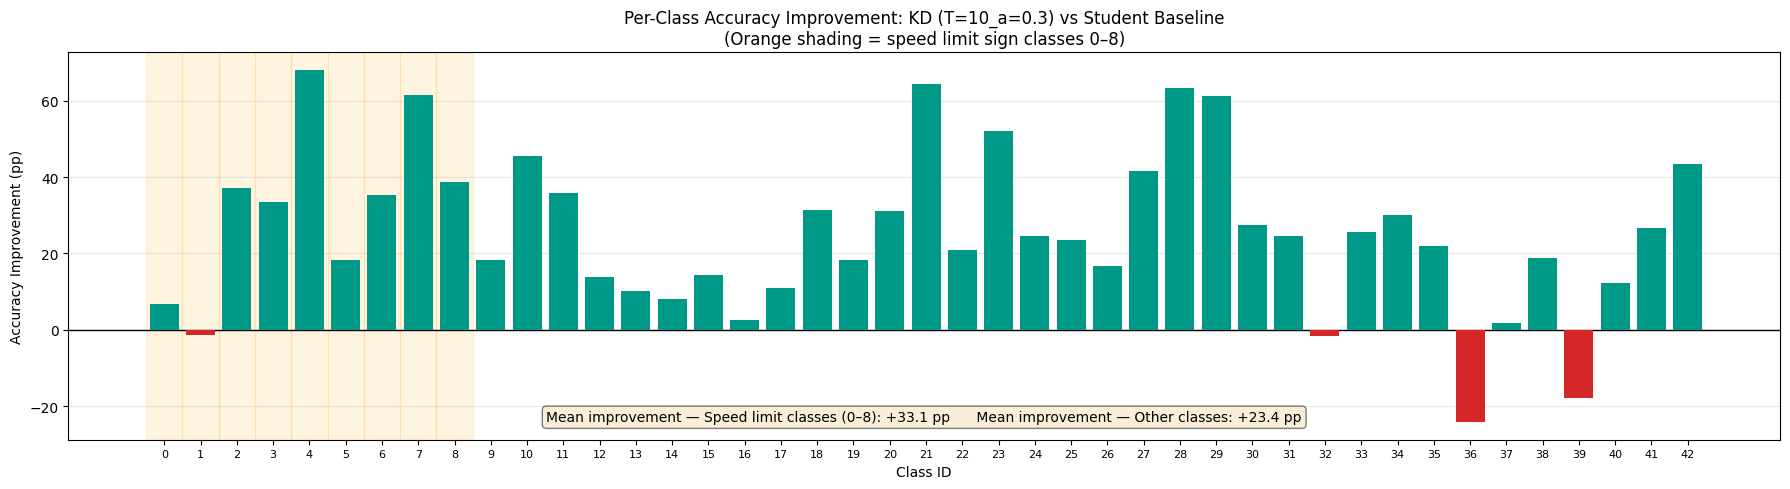

Saved: confusion_matrix_per_class.png

Confusion Matrix Analysis Summary
Overall accuracy — Baseline : 54.12%
Overall accuracy — KD best  : 80.97%

Speed limit classes (0–8):
  Baseline : 38.17%
  KD best  : 72.73%

Mean per-class improvement:
  Speed limit classes : +33.11 pp
  Other classes       : +23.44 pp


In [10]:
# Cell 9: Confusion Matrix Analysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_key   = max(kd_results, key=kd_results.get)
best_model = kd_students[best_key]
print(f"Best KD condition: {best_key}  ({kd_results[best_key]:.2%})")

X_test_list, y_test_list = [], []
for x_batch, y_batch in val_ds:
    X_test_list.append(x_batch.numpy())
    y_test_list.append(y_batch.numpy())

X_test = np.concatenate(X_test_list, axis=0)
y_true = np.concatenate(y_test_list, axis=0)

y_pred_baseline = np.argmax(
    student_baseline.predict(X_test, batch_size=64, verbose=0), axis=1
)
y_pred_kd = np.argmax(
    best_model.predict(X_test, batch_size=64, verbose=0), axis=1
)

print(f"\nBaseline accuracy  : {np.mean(y_pred_baseline == y_true):.2%}")
print(f"KD ({best_key}) accuracy: {np.mean(y_pred_kd == y_true):.2%}")

# Figure 1 — Full 43×43 Confusion Matrix (Baseline vs Best KD)
cm_baseline = confusion_matrix(y_true, y_pred_baseline, labels=list(range(num_classes)))
cm_kd       = confusion_matrix(y_true, y_pred_kd,       labels=list(range(num_classes)))

fig1, axes1 = plt.subplots(1, 2, figsize=(22, 10))
fig1.suptitle(
    f'Full Confusion Matrix (43 Classes)\n'
    f'Left: Student Baseline  |  Right: Student + KD ({best_key})',
    fontsize=13, fontweight='bold'
)

for ax, cm, title in zip(
    axes1,
    [cm_baseline, cm_kd],
    [f'Student Baseline ({np.mean(y_pred_baseline == y_true):.2%})',
     f'Student + KD {best_key} ({np.mean(y_pred_kd == y_true):.2%})']
):
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(range(num_classes), fontsize=6, rotation=90)
    ax.set_yticklabels(range(num_classes), fontsize=6)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('confusion_matrix_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_full.png")

# Figure 2 — Speed Limit Sign Subset (Classes 0–8)
SPEED_CLASSES = list(range(9))
speed_labels  = ['20', '30', '50', '60', '70', '80', 'end80', '100', '120']

mask          = np.isin(y_true, SPEED_CLASSES)
y_true_speed  = y_true[mask]
y_pred_b_speed = y_pred_baseline[mask]
y_pred_k_speed = y_pred_kd[mask]

cm_b_speed = confusion_matrix(y_true_speed, y_pred_b_speed, labels=SPEED_CLASSES)
cm_k_speed = confusion_matrix(y_true_speed, y_pred_k_speed, labels=SPEED_CLASSES)

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7))
fig2.suptitle(
    'Speed Limit Sign Subset — Confusion Matrix (Classes 0–8)\n'
    'Verifying hypothesis: KD gains concentrated in visually confusable subgroups',
    fontsize=13, fontweight='bold'
)

for ax, cm, y_pred_s, title in zip(
    axes2,
    [cm_b_speed, cm_k_speed],
    [y_pred_b_speed, y_pred_k_speed],
    [f'Student Baseline\n({np.mean(y_pred_b_speed == y_true_speed):.2%} on speed limit classes)',
     f'Student + KD ({best_key})\n({np.mean(y_pred_k_speed == y_true_speed):.2%} on speed limit classes)']
):
    im = ax.imshow(cm, interpolation='nearest', cmap='Oranges')
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel('Predicted Class', fontsize=10)
    ax.set_ylabel('True Class', fontsize=10)
    ax.set_xticks(range(len(SPEED_CLASSES)))
    ax.set_yticks(range(len(SPEED_CLASSES)))
    ax.set_xticklabels(speed_labels, fontsize=10)
    ax.set_yticklabels(speed_labels, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Annotate each cell with count
    for i in range(len(SPEED_CLASSES)):
        for j in range(len(SPEED_CLASSES)):
            count = cm[i, j]
            color = 'white' if count > cm.max() * 0.6 else 'black'
            ax.text(j, i, str(count), ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_speed_limit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_speed_limit.png")


# Figure 3 — Per-class accuracy improvement (KD vs Baseline)
per_class_acc_baseline = []
per_class_acc_kd       = []

for c in range(num_classes):
    mask_c = (y_true == c)
    if mask_c.sum() == 0:
        per_class_acc_baseline.append(0.0)
        per_class_acc_kd.append(0.0)
    else:
        per_class_acc_baseline.append(np.mean(y_pred_baseline[mask_c] == c))
        per_class_acc_kd.append(np.mean(y_pred_kd[mask_c] == c))

improvement = np.array(per_class_acc_kd) - np.array(per_class_acc_baseline)

fig3, ax3 = plt.subplots(figsize=(18, 5))
bar_colors = ['#009988' if v >= 0 else '#d62728' for v in improvement]
ax3.bar(range(num_classes), improvement * 100, color=bar_colors, zorder=3)
ax3.axhline(0, color='black', lw=1)

for c in SPEED_CLASSES:
    ax3.axvspan(c - 0.5, c + 0.5, alpha=0.12, color='orange', zorder=0)

ax3.set_title(
    f'Per-Class Accuracy Improvement: KD ({best_key}) vs Student Baseline\n'
    f'(Orange shading = speed limit sign classes 0–8)',
    fontsize=12
)
ax3.set_xlabel('Class ID', fontsize=10)
ax3.set_ylabel('Accuracy Improvement (pp)', fontsize=10)
ax3.set_xticks(range(num_classes))
ax3.set_xticklabels(range(num_classes), fontsize=8)
ax3.grid(axis='y', alpha=0.3, zorder=0)

mean_speed = improvement[SPEED_CLASSES].mean() * 100
mean_other = improvement[[c for c in range(num_classes) if c not in SPEED_CLASSES]].mean() * 100
ax3.text(0.5, 0.04,
         f'Mean improvement — Speed limit classes (0–8): {mean_speed:+.1f} pp      '
         f'Mean improvement — Other classes: {mean_other:+.1f} pp',
         transform=ax3.transAxes, fontsize=10, va='bottom', ha='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('confusion_matrix_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_per_class.png")


# Summary 
print("\n" + "=" * 55)
print("Confusion Matrix Analysis Summary")
print("=" * 55)
print(f"Overall accuracy — Baseline : {np.mean(y_pred_baseline == y_true):.2%}")
print(f"Overall accuracy — KD best  : {np.mean(y_pred_kd == y_true):.2%}")
print(f"\nSpeed limit classes (0–8):")
print(f"  Baseline : {np.mean(y_pred_b_speed == y_true_speed):.2%}")
print(f"  KD best  : {np.mean(y_pred_k_speed == y_true_speed):.2%}")
print(f"\nMean per-class improvement:")
print(f"  Speed limit classes : {mean_speed:+.2f} pp")
print(f"  Other classes       : {mean_other:+.2f} pp")